# Chapter 2, Example 6: A Dynamic Graphical Model and Stochastic Generation

A static graphical model describes a probability distribution over one configuration. A dynamic graphical model describes a probability distribution over an entire trajectory.

This notebook develops a binary activation process on a four-node network. Each time step is conditionally independent across nodes given the previous network state. We construct the exact transition matrix, propagate the state distribution, generate sample trajectories, and compare exact inference with Monte Carlo estimation.

The model provides an early bridge from graphical models to Markov processes, autoregressive generation, discrete diffusion, stochastic control, and bridge sampling.

## 1. Local transition factors

Let $X_{t,i}\in\{0,1\}$ denote the state of node $i$ at time $t$. The transition probability factorizes as

$$
p(\boldsymbol{x}_{t+1}\mid\boldsymbol{x}_t)
=
\prod_{i=1}^{4}
p_i(x_{t+1,i}\mid\boldsymbol{x}_{t}).
$$

We use logistic local probabilities,

$$
p_i(X_{t+1,i}=1\mid\boldsymbol{x}_t)
=
\sigma\left(
 b_i
 +a x_{t,i}
 +c\sum_{j\in\mathcal{N}(i)}x_{t,j}
\right),
$$

where $a$ controls persistence, $c$ controls propagation through network edges, and $b_i$ controls spontaneous activation.

The path distribution is

$$
p(\boldsymbol{x}_{0:T})
=
p_0(\boldsymbol{x}_0)
\prod_{t=0}^{T-1}
\prod_{i=1}^{4}
p_i(x_{t+1,i}\mid\boldsymbol{x}_t).
$$

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Publication-oriented typography shared by all Chapter 2 figures.
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
    "lines.linewidth": 2.0,
})

CWD = Path.cwd()
if CWD.name == "ch02":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch02").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch02"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 220})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


def sigmoid(value):
    return 1.0 / (1.0 + np.exp(-value))

n = 4
spatial_edges = [(0, 1), (1, 2), (2, 3)]
neighbors = {i: [] for i in range(n)}
for i, j in spatial_edges:
    neighbors[i].append(j)
    neighbors[j].append(i)

bias = np.array([-2.6, -2.5, -2.5, -2.6])
persistence = 2.15
coupling = 1.55
T = 9
states = np.array(list(product([0, 1], repeat=n)), dtype=int)
state_to_index = {tuple(state): index for index, state in enumerate(states)}
initial_state = np.array([1, 0, 0, 0], dtype=int)
initial_distribution = np.zeros(len(states))
initial_distribution[state_to_index[tuple(initial_state)]] = 1.0

## 2. Spatial graph and time-unrolled graph

The spatial graph identifies which nodes influence each local transition. Unrolling the model in time produces a directed acyclic graph. Every node at time $t+1$ receives an arrow from its own previous value and from the previous values of its spatial neighbors.

Saved: figs/ch02_06_spatial_and_unrolled_graphs.pdf


Saved: figs/ch02_06_spatial_and_unrolled_graphs.png


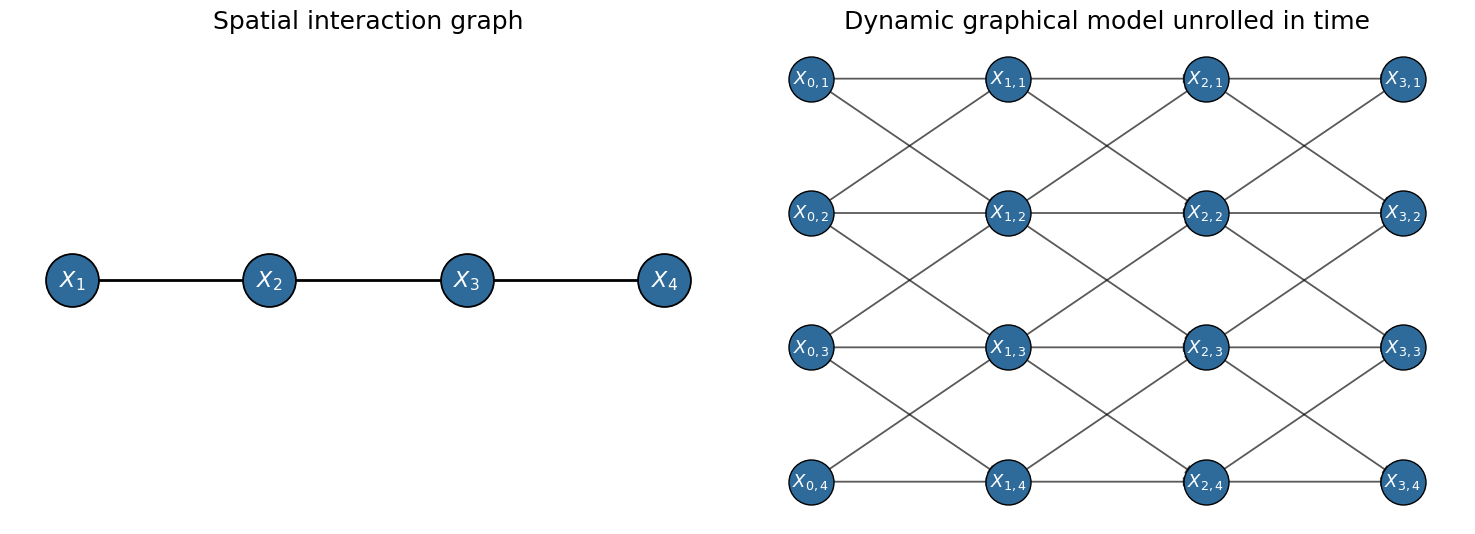

In [2]:
spatial_graph = nx.Graph(spatial_edges)
spatial_pos = {i: (i, 0) for i in range(n)}

unrolled = nx.DiGraph()
unroll_steps = 3
unrolled_pos = {}
for t in range(unroll_steps + 1):
    for i in range(n):
        node = (t, i)
        unrolled.add_node(node)
        unrolled_pos[node] = (t, -i)
for t in range(unroll_steps):
    for i in range(n):
        unrolled.add_edge((t, i), (t + 1, i))
        for j in neighbors[i]:
            unrolled.add_edge((t, j), (t + 1, i))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
nx.draw_networkx_edges(spatial_graph, spatial_pos, width=2.0, ax=axes[0])
nx.draw_networkx_nodes(spatial_graph, spatial_pos, node_size=1450, node_color="#2F6B9A", edgecolors="black", linewidths=1.3, ax=axes[0])
nx.draw_networkx_labels(spatial_graph, spatial_pos, labels={i: rf"$X_{{{i+1}}}$" for i in range(n)}, font_size=16, font_color="white", ax=axes[0])
axes[0].set_title("Spatial interaction graph")
axes[0].axis("off")

nx.draw_networkx_nodes(unrolled, unrolled_pos, node_size=1050, node_color="#2F6B9A", edgecolors="black", linewidths=1.0, ax=axes[1])
nx.draw_networkx_edges(unrolled, unrolled_pos, arrows=True, arrowsize=14, width=1.3, alpha=0.65, ax=axes[1])
nx.draw_networkx_labels(
    unrolled, unrolled_pos,
    labels={(t, i): rf"$X_{{{t},{i+1}}}$" for t in range(unroll_steps + 1) for i in range(n)},
    font_size=13, font_color="white", ax=axes[1]
)
axes[1].set_title("Dynamic graphical model unrolled in time")
axes[1].axis("off")
fig.tight_layout()
save_figure(fig, "ch02_06_spatial_and_unrolled_graphs")
plt.show()

## 3. Exact transition matrix

Because there are only $2^4=16$ network states, we can construct the complete transition matrix. For a given current state, the four next-state variables are conditionally independent, so each transition probability is a product of four Bernoulli probabilities.

In [3]:
def local_activation_probabilities(current_state, bias_vector=bias):
    probabilities = np.zeros(n)
    for i in range(n):
        neighbor_sum = sum(current_state[j] for j in neighbors[i])
        logit = bias_vector[i] + persistence * current_state[i] + coupling * neighbor_sum
        probabilities[i] = sigmoid(logit)
    return probabilities


def transition_probability(current_state, next_state, bias_vector=bias):
    activation = local_activation_probabilities(current_state, bias_vector)
    return float(np.prod(np.where(next_state == 1, activation, 1.0 - activation)))


def build_transition_matrix(bias_vector=bias):
    matrix = np.zeros((len(states), len(states)))
    for i, current in enumerate(states):
        for j, nxt in enumerate(states):
            matrix[i, j] = transition_probability(current, nxt, bias_vector)
    return matrix


P = build_transition_matrix()
row_errors = np.abs(P.sum(axis=1) - 1.0)
print("Maximum transition-row normalization error:", row_errors.max())
assert row_errors.max() < 1e-12

Maximum transition-row normalization error: 1.1102230246251565e-16


## 4. Exact propagation of state probabilities

The distribution evolves according to

$$
\boldsymbol{\pi}_{t+1}=\boldsymbol{\pi}_{t}P.
$$

From the exact state distribution we obtain each node marginal by summing over the other network variables.

In [4]:
exact_distributions = [initial_distribution]
for _ in range(T):
    exact_distributions.append(exact_distributions[-1] @ P)
exact_distributions = np.array(exact_distributions)

exact_marginals = exact_distributions @ states
assert np.allclose(exact_distributions.sum(axis=1), 1.0)

marginal_table = pd.DataFrame(
    exact_marginals,
    columns=[f"P(X{i+1}=1)" for i in range(n)],
)
marginal_table.index.name = "time"
display(marginal_table.round(4))

,P(X1=1),P(X2=1),P(X3=1),P(X4=1)
time,,,,
0,1.0000,0.0000,0.0000,0.0000
1,0.3894,0.2789,0.0759,0.0691
2,0.2654,0.2862,0.1788,0.1066
3,0.2289,0.2900,0.2330,0.1424
4,0.2178,0.2972,0.2662,0.1690
5,0.2157,0.3059,0.2887,0.1879
6,0.2170,0.3147,0.3050,0.2012
7,0.2197,0.3228,0.3173,0.2107
8,0.2228,0.3298,0.3267,0.2176


## 5. Stochastic generation of trajectories

A trajectory is generated sequentially. At each step we compute the local activation probabilities from the current state and sample the next node states independently.

In [5]:
def sample_trajectory(rng, horizon=T, start=initial_state, bias_vector=bias):
    trajectory = np.zeros((horizon + 1, n), dtype=int)
    trajectory[0] = start
    for t in range(horizon):
        probabilities = local_activation_probabilities(trajectory[t], bias_vector)
        trajectory[t + 1] = rng.binomial(1, probabilities)
    return trajectory


def trajectory_probability(trajectory, bias_vector=bias):
    value = 1.0
    for t in range(len(trajectory) - 1):
        value *= transition_probability(trajectory[t], trajectory[t + 1], bias_vector)
    return value


num_trajectories = 12000
trajectories = np.array([sample_trajectory(RNG) for _ in range(num_trajectories)])
mc_marginals = trajectories.mean(axis=0)

example = trajectories[0]
print("One generated trajectory:")
display(pd.DataFrame(example, columns=[f"X{i+1}" for i in range(n)]))
print("Exact probability of this trajectory:", trajectory_probability(example))

One generated trajectory:


,X1,X2,X3,X4
0,1,0,0,0
1,1,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0
5,0,0,0,0
6,0,0,0,0
7,0,0,0,0
8,0,0,0,0
9,0,1,0,0


Exact probability of this trajectory: 0.0009128294232641981


## 6. Exact inference versus Monte Carlo

The exact and empirical marginals should agree. Their comparison also shows how activation propagates from the initially active first node through the chain.

Saved: figs/ch02_06_exact_and_monte_carlo_marginals.pdf


Saved: figs/ch02_06_exact_and_monte_carlo_marginals.png


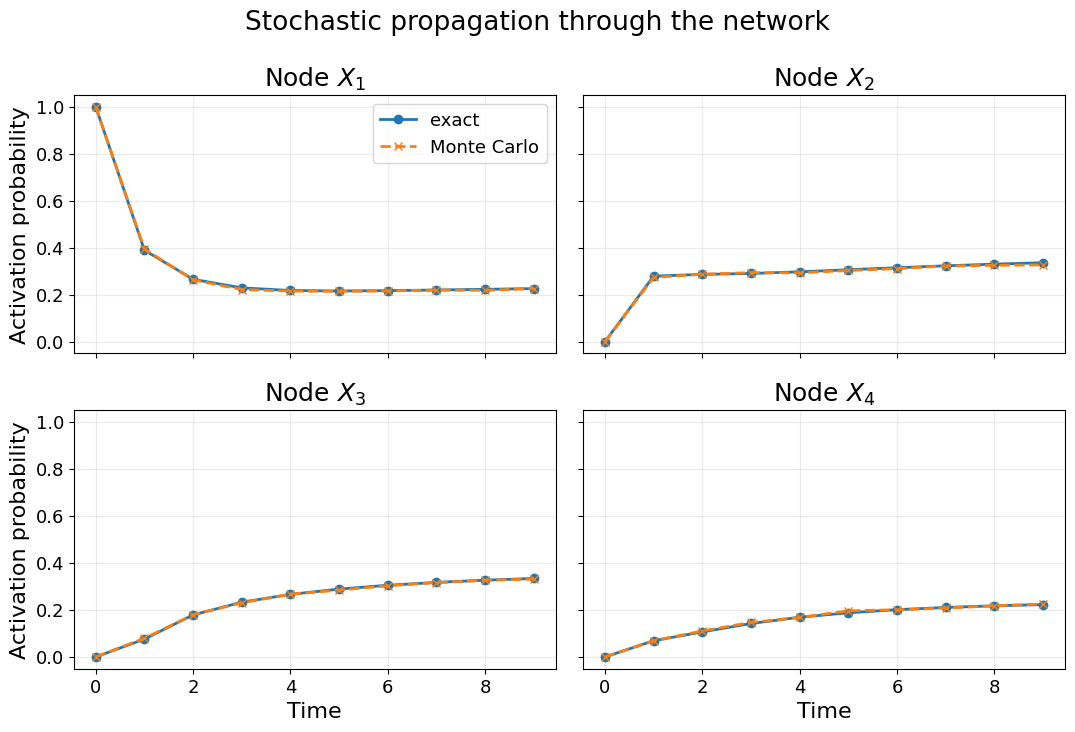

Maximum marginal Monte Carlo error: 0.009020971990658322


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True, sharey=True)
time = np.arange(T + 1)
for i, ax in enumerate(axes.flat):
    ax.plot(time, exact_marginals[:, i], marker="o", label="exact")
    ax.plot(time, mc_marginals[:, i], linestyle="--", marker="x", label="Monte Carlo")
    ax.set_title(rf"Node $X_{i+1}$")
    ax.grid(alpha=0.25)
    if i >= 2:
        ax.set_xlabel("Time")
    if i % 2 == 0:
        ax.set_ylabel("Activation probability")
axes[0, 0].legend()
fig.suptitle("Stochastic propagation through the network")
fig.tight_layout()
save_figure(fig, "ch02_06_exact_and_monte_carlo_marginals")
plt.show()

max_error = np.max(np.abs(exact_marginals - mc_marginals))
print("Maximum marginal Monte Carlo error:", max_error)
assert max_error < 0.035

## 7. Visualizing generated paths

A single state probability does not display the diversity of complete paths. The next figure shows ten independently generated trajectories. Each row within a trajectory corresponds to one node, and each column corresponds to one time.

Saved: figs/ch02_06_generated_trajectories.pdf


Saved: figs/ch02_06_generated_trajectories.png


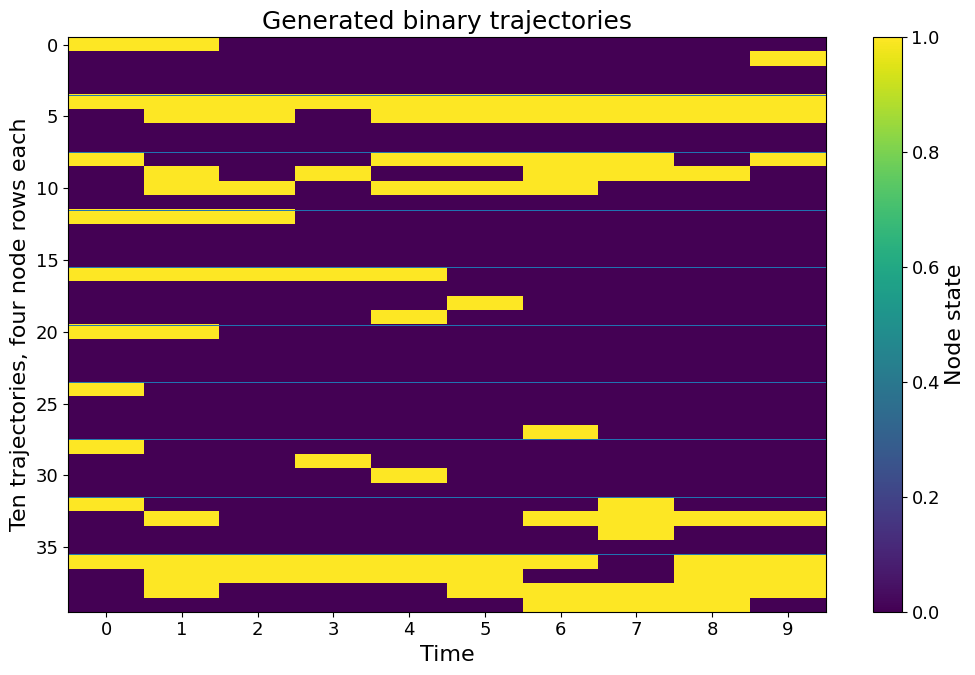

In [7]:
selected = trajectories[:10]
stacked = selected.transpose(0, 2, 1).reshape(10 * n, T + 1)

fig, ax = plt.subplots(figsize=(10.5, 7))
image = ax.imshow(stacked, aspect="auto", interpolation="nearest", vmin=0, vmax=1)
for boundary in range(n, 10 * n, n):
    ax.axhline(boundary - 0.5, linewidth=0.7)
ax.set_xlabel("Time")
ax.set_ylabel("Ten trajectories, four node rows each")
ax.set_title("Generated binary trajectories")
ax.set_xticks(range(T + 1))
fig.colorbar(image, ax=ax, label="Node state")
fig.tight_layout()
save_figure(fig, "ch02_06_generated_trajectories")
plt.show()

## 8. Distribution of the number of active nodes

Define

$$
N_t=\sum_{i=1}^{4}X_{t,i}.
$$

The full state distribution determines the probability of every possible active-node count. This observable compresses the network state while retaining information about the growth and decay of activity.

Saved: figs/ch02_06_active_count_distribution.pdf
Saved: figs/ch02_06_active_count_distribution.png


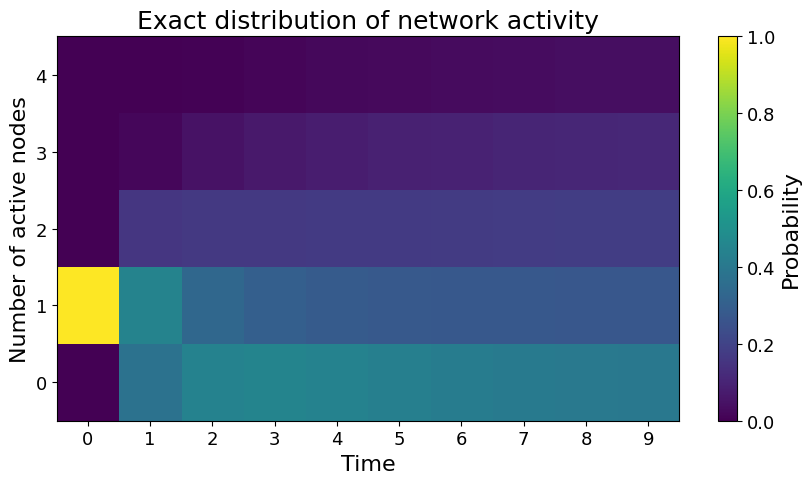

In [8]:
active_counts = states.sum(axis=1)
count_distribution = np.zeros((T + 1, n + 1))
for t in range(T + 1):
    for count in range(n + 1):
        count_distribution[t, count] = exact_distributions[t, active_counts == count].sum()

fig, ax = plt.subplots(figsize=(8.7, 5.1))
image = ax.imshow(count_distribution.T, aspect="auto", origin="lower", vmin=0)
ax.set_xlabel("Time")
ax.set_ylabel("Number of active nodes")
ax.set_xticks(range(T + 1))
ax.set_yticks(range(n + 1))
ax.set_title("Exact distribution of network activity")
fig.colorbar(image, ax=ax, label="Probability")
fig.tight_layout()
save_figure(fig, "ch02_06_active_count_distribution")
plt.show()

## 9. Monte Carlo convergence in total variation distance

For a distribution $p$ and empirical estimate $\widehat p$, total variation distance is

$$
d_{\mathrm{TV}}(p,\widehat p)
=
\frac{1}{2}\sum_x|p(x)-\widehat p(x)|.
$$

We compare the exact final-time state distribution with estimates based on increasing numbers of trajectories.

Saved: figs/ch02_06_monte_carlo_convergence.pdf
Saved: figs/ch02_06_monte_carlo_convergence.png


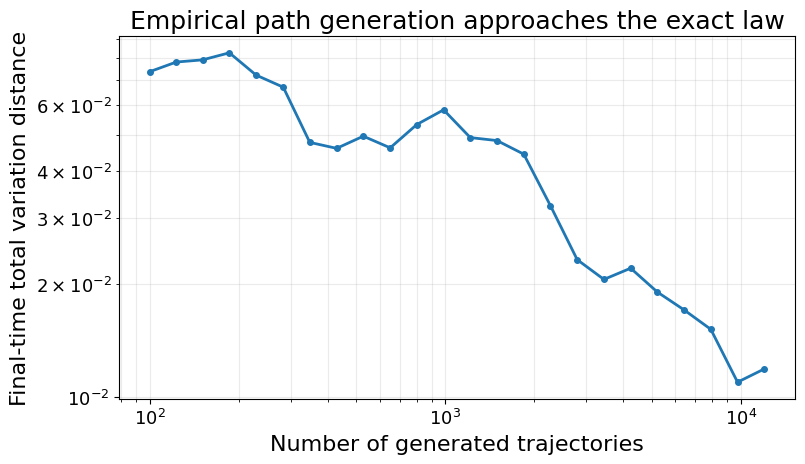

In [9]:
sample_sizes = np.unique(np.logspace(2, np.log10(num_trajectories), 24).astype(int))
final_indices = np.array([state_to_index[tuple(path[-1])] for path in trajectories])
tv_errors = []
for size in sample_sizes:
    empirical = np.bincount(final_indices[:size], minlength=len(states)) / size
    tv_errors.append(0.5 * np.abs(empirical - exact_distributions[-1]).sum())

fig, ax = plt.subplots(figsize=(8.3, 4.9))
ax.loglog(sample_sizes, tv_errors, marker="o", markersize=4)
ax.set_xlabel("Number of generated trajectories")
ax.set_ylabel("Final-time total variation distance")
ax.set_title("Empirical path generation approaches the exact law")
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch02_06_monte_carlo_convergence")
plt.show()

## 10. Final-time distribution

The final distribution is supported on all sixteen network states, but the probabilities are highly nonuniform. The figure makes visible which global configurations are favored after the initial activation has propagated and partially decayed.

Saved: figs/ch02_06_final_state_distribution.pdf
Saved: figs/ch02_06_final_state_distribution.png


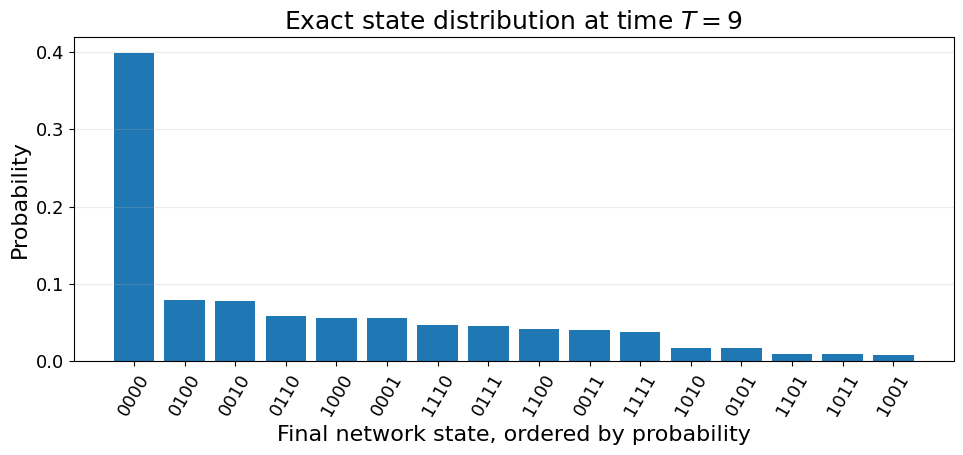

In [10]:
labels = ["".join(str(v) for v in state) for state in states]
order = np.argsort(exact_distributions[-1])[::-1]
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(np.arange(len(states)), exact_distributions[-1, order])
ax.set_xticks(np.arange(len(states)), np.array(labels)[order], rotation=60)
ax.set_xlabel("Final network state, ordered by probability")
ax.set_ylabel("Probability")
ax.set_title(rf"Exact state distribution at time $T={T}$")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch02_06_final_state_distribution")
plt.show()

## 11. Interpretation

This example combines a graph in space with a graph in time. The local transition factors define both an inference problem and a generative mechanism:

- forward multiplication by $P$ computes exact time-dependent marginals;
- sequential Bernoulli draws generate complete paths;
- path probabilities factor into local transition probabilities;
- the state space grows exponentially with the number of network nodes;
- exact propagation therefore becomes difficult for larger systems.

Later chapters will replace the exact transition matrix by message passing, Monte Carlo, learned transition models, reverse-time processes, bridge constraints, and stochastic control.

## 12. Exercises

### Exercise 1: Change persistence and propagation

Vary $a$ and $c$. Identify regimes dominated by local persistence and regimes dominated by propagation through neighbors.

### Exercise 2: Different initial conditions

Repeat the experiment from the all-zero state, the all-one state, and a central seed. Compare the resulting marginal trajectories.

### Exercise 3: Add a shortcut edge

Add the spatial edge $(1,3)$ using zero-based node indices. Rebuild the dynamic graph and study how quickly activation reaches the last node.

### Exercise 4: A time-dependent intervention

After time $t=3$, increase the bias of the last node. Simulate the nonhomogeneous process and compare it with the original dynamics.

### Exercise 5: Rare-event probability

Compute the probability that all four nodes are active at least once before time $T$. Compare direct Monte Carlo with exact dynamic programming on an augmented state space.

### Exercise 6: Parameter learning

Generate trajectories from hidden values of $a$ and $c$. Write the log-likelihood and estimate the parameters numerically.

### Exercise 7: Endpoint conditioning

Condition on the event that the final state is $1111$. Use rejection sampling as a baseline. Explain why a bridge or controlled process may be much more efficient when the event is rare.

### Exercise 8: Reverse-time transition

Using the exact marginals, compute

$$
p(\boldsymbol{x}_t\mid\boldsymbol{x}_{t+1})
=
\frac{p(\boldsymbol{x}_{t+1}\mid\boldsymbol{x}_t)p_t(\boldsymbol{x}_t)}
{p_{t+1}(\boldsymbol{x}_{t+1})}.
$$

Verify that the reverse-time rows normalize and discuss their time dependence.